# 1 Introducción y Contexto

## Descripción del dataset

El dataset utilizado proviene de Kaggle y está basado en el BRFSS (Behavioral Risk Factor Surveillance System). Este es un sistema de encuestas en Estados Unidos que recoge información sobre la salud de las personas, sus hábitos y enfermedades.

El dataset original (BRFSS) fue previamente limpiado y reducido de más de 300 variables a 19 variables importantes relacionadas con el estilo de vida, como actividad física, consumo de alcohol, tabaquismo, salud general, entre otras.

Este conjunto de datos representa factores personales que pueden influir en el riesgo de sufrir enfermedades cardiovasculares.

## Contexto del problema

Las enfermedades cardiovasculares son una de las principales causas de muerte en el mundo. Muchos de los factores que influyen en estas enfermedades estan relacionados con el estilo de vida de las personas. Por lo tanto, analizar este tipo de datos permite entender mejor qué habitos o condiciones estan mas relacionados con el riesgo de tener problemas del corazon.

## Justificación

Este dataset es importante porque tiene datos reales de personas y permite analizarocómo diferentesahábitos influyen en la salud.

Desde el punto de vista eitadístico,ues útil porque tiene varias variablesenuméricas y cotegóricas, lo que permite aplicar diferentes análisis como promedios, frecuenciy correlacionesu s.
a
Además, el tema es fácil de interpretar y tiene impacto en la vida

## Preguntas de investigación

1 ¿Las personas que no realizan actividadsfísica tienen mayor riesgo de enfermedad cardiovascular?

2. ¿El consumo de alcoholaestá relacionado con la presencia de enfermedad cardiovascular?

3. ¿Las personas con peor salud general tienen mayor probabilidad de tener enfermedad cardiovas

## Hipótesis preliminares

### Pregunta 1
**Hipótesis:** Las personas que no realizan actividai física tienen mayor riesgo de enfermedad cardiovascular.

### Pregunta 2
**Hipótesis:** El consumo de alcohal está relacionado con un mayor riesgo de enfermedad cardiovascular.

### Pregunta 3
**Hipótesis:** Las personas con peor estado de salud general tienen mayor probabilidad de presentar enfermedad cardiovascular.cular? real.

# 2 Carga y Exploración Inicial

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Parcial1_Analisis_Exploratorio") \
    .getOrCreate()
df = spark.read.csv("/home/jovyan/work/data/CVD_cleaned.csv", header=True, inferSchema=True)

In [3]:
df.printSchema()

root
 |-- General_Health: string (nullable = true)
 |-- Checkup: string (nullable = true)
 |-- Exercise: string (nullable = true)
 |-- Heart_Disease: string (nullable = true)
 |-- Skin_Cancer: string (nullable = true)
 |-- Other_Cancer: string (nullable = true)
 |-- Depression: string (nullable = true)
 |-- Diabetes: string (nullable = true)
 |-- Arthritis: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age_Category: string (nullable = true)
 |-- Height_(cm): double (nullable = true)
 |-- Weight_(kg): double (nullable = true)
 |-- BMI: double (nullable = true)
 |-- Smoking_History: string (nullable = true)
 |-- Alcohol_Consumption: double (nullable = true)
 |-- Fruit_Consumption: double (nullable = true)
 |-- Green_Vegetables_Consumption: double (nullable = true)
 |-- FriedPotato_Consumption: double (nullable = true)



In [ ]:
## Interpretación del esquema

El dataset tiene dos tipos de variables: categóricas (string) y numéricas (double).

### Variables categóricas 

- **General_Health:** estado de salud general de la persona  
- **Checkup:** si la persona se ha hecho chequeos médicos  
- **Exercise:** si realiza ejercicio  
- **Heart_Disease:** si tiene enfermedad cardíaca  
- **Skin_Cancer / Other_Cancer:** si ha tenido cáncer  
- **Depression:** si ha tenido depresión  
- **Diabetes:** si tiene diabetes  
- **Arthritis:** si tiene artritis  
- **Sex:** sexo de la persona  
- **Age_Category:** rango de edad  
- **Smoking_History:** historial de tabaquismo  

### Variables numéricas 

- **Height_(cm):** altura en centímetros  
- **Weight_(kg):** peso en kilogramos  
- **BMI:** índice de masa corporal  
- **Alcohol_Consumption:** consumo de alcohol  
- **Fruit_Consumption:** consumo de frutas  
- **Green_Vegetables_Consumption:** consumo de verduras  
- **FriedPotato_Consumption:** consumo de comida frita  


In [5]:
filas = df.count()
columnas = len(df.columns)

print("Número de filas:", filas)
print("Número de columnas:", columnas)

Número de filas: 308854
Número de columnas: 19


In [6]:
df.show(10, truncate=False)

+--------------+-----------------------+--------+-------------+-----------+------------+----------+--------+---------+------+------------+-----------+-----------+-----+---------------+-------------------+-----------------+----------------------------+-----------------------+
|General_Health|Checkup                |Exercise|Heart_Disease|Skin_Cancer|Other_Cancer|Depression|Diabetes|Arthritis|Sex   |Age_Category|Height_(cm)|Weight_(kg)|BMI  |Smoking_History|Alcohol_Consumption|Fruit_Consumption|Green_Vegetables_Consumption|FriedPotato_Consumption|
+--------------+-----------------------+--------+-------------+-----------+------------+----------+--------+---------+------+------------+-----------+-----------+-----+---------------+-------------------+-----------------+----------------------------+-----------------------+
|Poor          |Within the past 2 years|No      |No           |No         |No          |No        |No      |Yes      |Female|70-74       |150.0      |32.66      |14.54|Yes 

In [7]:
from pyspark.sql.functions import col, sum, when

df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]).show()

+--------------+-------+--------+-------------+-----------+------------+----------+--------+---------+---+------------+-----------+-----------+---+---------------+-------------------+-----------------+----------------------------+-----------------------+
|General_Health|Checkup|Exercise|Heart_Disease|Skin_Cancer|Other_Cancer|Depression|Diabetes|Arthritis|Sex|Age_Category|Height_(cm)|Weight_(kg)|BMI|Smoking_History|Alcohol_Consumption|Fruit_Consumption|Green_Vegetables_Consumption|FriedPotato_Consumption|
+--------------+-------+--------+-------------+-----------+------------+----------+--------+---------+---+------------+-----------+-----------+---+---------------+-------------------+-----------------+----------------------------+-----------------------+
|             0|      0|       0|            0|          0|           0|         0|       0|        0|  0|           0|          0|          0|  0|              0|                  0|                0|                           0|     

## Identificación de valores nulos

Se realizo un conteo de valores nulos en cada columna del dataset.

Como resultado, se observa que todas las variables tienen valor 0 en nulos lo que significa que no hay datos faltantes en el conjunto de datos.

## Tratamiento de valores nulos
Dado que no se encontraron valores nulos, no fue necesario aplicar ningun metodo de limpieza o imputación.

Esto permite trabajar directamente con el dataset sin realizar modificaciones adicionales en esta parte.

# 3 Estadistica Descriptiva 

In [8]:
columnas_numericas = [
    "Alcohol_Consumption",
    "BMI",
    "Weight_(kg)",
    "Height_(cm)",
    "Fruit_Consumption",
    "Green_Vegetables_Consumption",
    "FriedPotato_Consumption"
]

print(columnas_numericas)

['Alcohol_Consumption', 'BMI', 'Weight_(kg)', 'Height_(cm)', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']


In [9]:
from pyspark.sql.functions import avg

df.select(
    avg("Alcohol_Consumption"),
    avg("BMI"),
    avg("Weight_(kg)"),
    avg("Height_(cm)"),
    avg("Fruit_Consumption"),
    avg("Green_Vegetables_Consumption"),
    avg("FriedPotato_Consumption")
).show()

+------------------------+-----------------+-----------------+------------------+----------------------+---------------------------------+----------------------------+
|avg(Alcohol_Consumption)|         avg(BMI)| avg(Weight_(kg))|  avg(Height_(cm))|avg(Fruit_Consumption)|avg(Green_Vegetables_Consumption)|avg(FriedPotato_Consumption)|
+------------------------+-----------------+-----------------+------------------+----------------------+---------------------------------+----------------------------+
|       5.096365920467276|28.62621053960776|83.58865454228014|170.61524862880196|    29.835200450698387|               15.110440531772294|           6.296615876757302|
+------------------------+-----------------+-----------------+------------------+----------------------+---------------------------------+----------------------------+



In [10]:
df.approxQuantile(columnas_numericas, [0.5],0.01)

[[1.0], [27.44], [81.65], [170.0], [30.0], [12.0], [4.0]]

## Medidas de tendencia central

Se calcularon la media y la mediana de las variables neméricas seleccionadación

- **Alcohol_Consumption:**  
  La media es aproximadamente 5.09 y la mediana es 1.0.  
  Esto indica que ia mayoría de personas consumen poco alcohol, pero hay algunos valores altos que aumentan el romedio.

- **BMI:**  
  La media es 28.63 y la mediana es 27.44.  
  Los valores son cercanos, lo que indica que las datos están relativamente quilibrados.

- **Weight_(kg):**  
  La media es 83.58 y la mediana es 81.65.  
  No hay mucha diferencia, por lo que no hay grandes alores extremos.

- **Height_(cm):**  
  La media es 170.61 y la mediana es 170.0.  
  Los datosestán muy centrados.

- **Fruit_Consumption:**  
  La media es 29.83 y la mediana es 30.0.  
  Indica un consumo bastante esable entre las personas.

- **Green_Vegetables_Consumption:**  
  La media es 15.11 y la mediana es 12.0.  
  Hay una pequeña diferencia, lo que pueae indicar algunos valores más altos.

- **FriedPotato_Consumption:**  
  La media es 6.29 y la mediana es 4.0.  
  La media es mayor que la mediana, lo que indica quera una distribución más equilibrada.

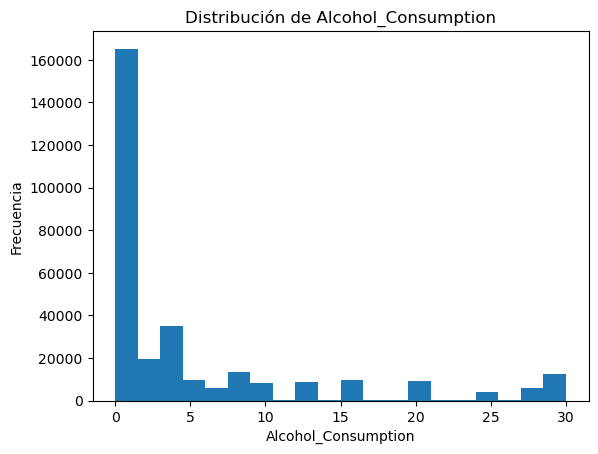

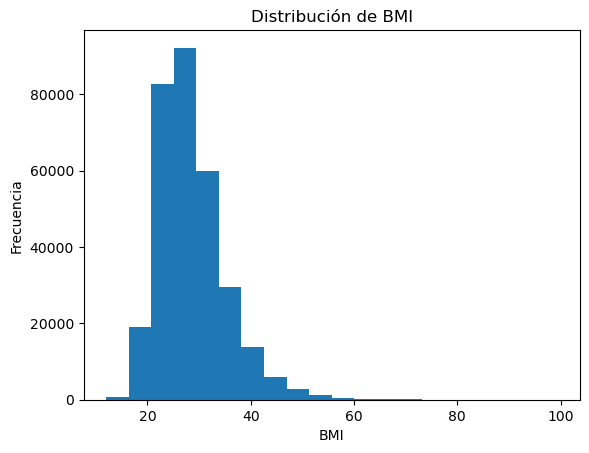

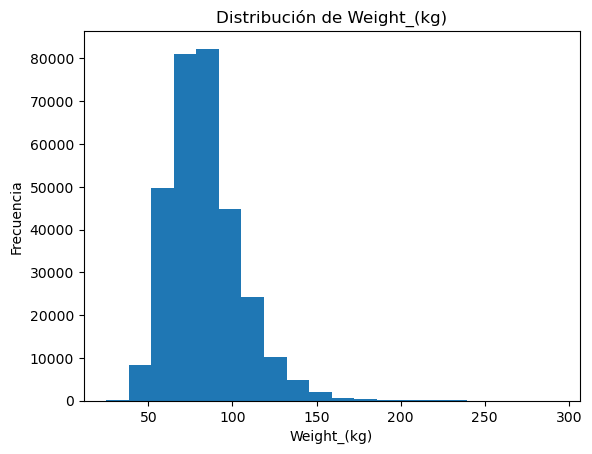

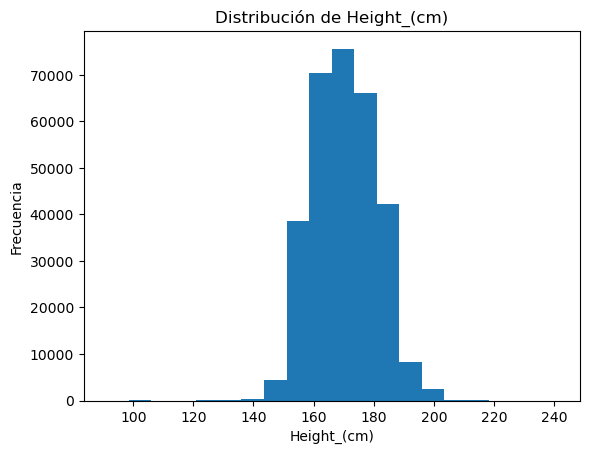

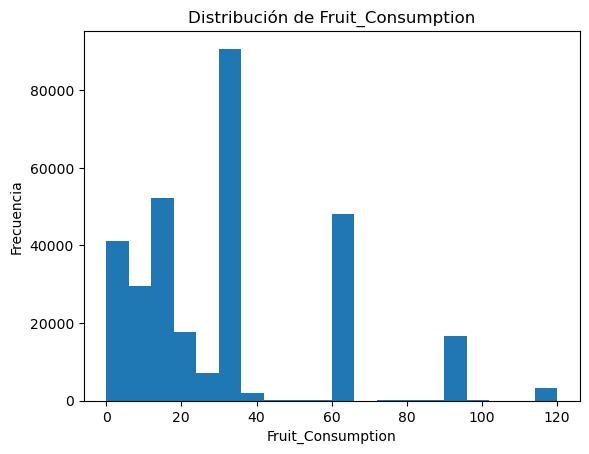

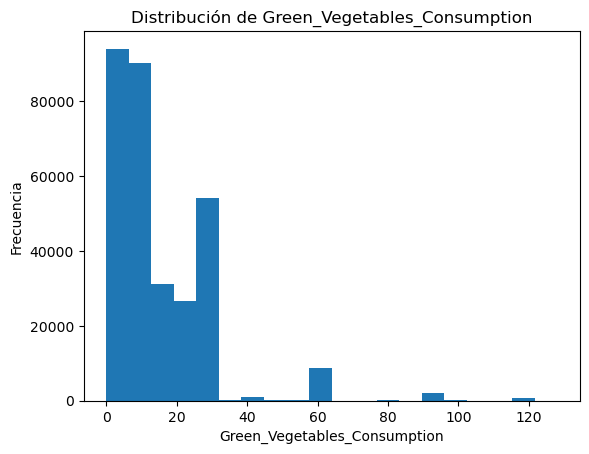

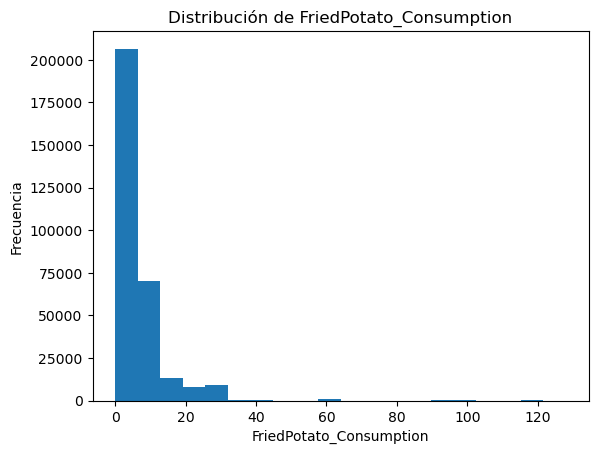

In [12]:

import matplotlib.pyplot as plt

columnas_numericas = [
    "Alcohol_Consumption",
    "BMI",
    "Weight_(kg)",
    "Height_(cm)",
    "Fruit_Consumption",
    "Green_Vegetables_Consumption",
    "FriedPotato_Consumption"
]

pdf = df.select(columnas_numericas).toPandas()

for col in columnas_numericas:
    plt.figure()
    plt.hist(pdf[col].dropna(), bins=20)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

## Medidas de dispersion

Se calcularon la desviación estandar, varianza, rango e IQR para las variables numericas

In [13]:
from pyspark.sql.functions import stddev

df.select(
    stddev("Alcohol_Consumption"),
    stddev("BMI"),
    stddev("Weight_(kg)"),
    stddev("Height_(cm)"),
    stddev("Fruit_Consumption"),
    stddev("Green_Vegetables_Consumption"),
    stddev("FriedPotato_Consumption")
).show()

+---------------------------+------------------+-------------------+-------------------+-------------------------+------------------------------------+-------------------------------+
|stddev(Alcohol_Consumption)|       stddev(BMI)|stddev(Weight_(kg))|stddev(Height_(cm))|stddev(Fruit_Consumption)|stddev(Green_Vegetables_Consumption)|stddev(FriedPotato_Consumption)|
+---------------------------+------------------+-------------------+-------------------+-------------------------+------------------------------------+-------------------------------+
|          8.199762520952028|6.5223230946946815|  21.34320976303954|  10.65802605214267|       24.875735359676774|                  14.926238423594944|              8.582954204157685|
+---------------------------+------------------+-------------------+-------------------+-------------------------+------------------------------------+-------------------------------+



In [14]:
from pyspark.sql.functions import variance

df.select(
    variance("Alcohol_Consumption"),
    variance("BMI"),
    variance("Weight_(kg)"),
    variance("Height_(cm)"),
    variance("Fruit_Consumption"),
    variance("Green_Vegetables_Consumption"),
    variance("FriedPotato_Consumption")
).show()

+-----------------------------+----------------+---------------------+---------------------+---------------------------+--------------------------------------+---------------------------------+
|var_samp(Alcohol_Consumption)|   var_samp(BMI)|var_samp(Weight_(kg))|var_samp(Height_(cm))|var_samp(Fruit_Consumption)|var_samp(Green_Vegetables_Consumption)|var_samp(FriedPotato_Consumption)|
+-----------------------------+----------------+---------------------+---------------------+---------------------------+--------------------------------------+---------------------------------+
|            67.23610540000956|42.5406985515876|    455.5326029891063|   113.59351932815187|          618.8022096846734|                     222.7925934780021|                73.66710287066809|
+-----------------------------+----------------+---------------------+---------------------+---------------------------+--------------------------------------+---------------------------------+



In [15]:
from pyspark.sql.functions import max, min

df.select(
    (max("Alcohol_Consumption") - min("Alcohol_Consumption")),
    (max("BMI") - min("BMI")),
    (max("Weight_(kg)") - min("Weight_(kg)")),
    (max("Height_(cm)") - min("Height_(cm)")),
    (max("Fruit_Consumption") - min("Fruit_Consumption")),
    (max("Green_Vegetables_Consumption") - min("Green_Vegetables_Consumption")),
    (max("FriedPotato_Consumption") - min("FriedPotato_Consumption"))
).show()

+-----------------------------------------------------+---------------------+-------------------------------------+-------------------------------------+-------------------------------------------------+-----------------------------------------------------------------------+-------------------------------------------------------------+
|(max(Alcohol_Consumption) - min(Alcohol_Consumption))|(max(BMI) - min(BMI))|(max(Weight_(kg)) - min(Weight_(kg)))|(max(Height_(cm)) - min(Height_(cm)))|(max(Fruit_Consumption) - min(Fruit_Consumption))|(max(Green_Vegetables_Consumption) - min(Green_Vegetables_Consumption))|(max(FriedPotato_Consumption) - min(FriedPotato_Consumption))|
+-----------------------------------------------------+---------------------+-------------------------------------+-------------------------------------+-------------------------------------------------+-----------------------------------------------------------------------+-------------------------------------------------

In [16]:
columnas_numericas = [
    "Alcohol_Consumption",
    "BMI",
    "Weight_(kg)",
    "Height_(cm)",
    "Fruit_Consumption",
    "Green_Vegetables_Consumption",
    "FriedPotato_Consumption"
]

quantiles = df.approxQuantile(columnas_numericas, [0.25, 0.75], 0.01)

print("IQR por variable:")
for i, col in enumerate(columnas_numericas):
    q1 = quantiles[i][0]
    q3 = quantiles[i][1]
    print(col, ":", q3 - q1)

IQR por variable:
Alcohol_Consumption : 6.0
BMI : 7.41
Weight_(kg) : 27.209999999999994
Height_(cm) : 15.0
Fruit_Consumption : 18.0
Green_Vegetables_Consumption : 16.0
FriedPotato_Consumption : 6.0


## Asimetría (skewness) y curtosis

Se calcularon la asimetria y la curtosis para analizar la forma de la distribución de las variables


In [18]:
from pyspark.sql.functions import skewness, kurtosis
df.select(
    skewness("Alcohol_Consumption"),
    skewness("BMI"),
    skewness("Weight_(kg)"),
    skewness("Height_(cm)"),
    skewness("Fruit_Consumption"),
    skewness("Green_Vegetables_Consumption"),
    skewness("FriedPotato_Consumption"),
    
    kurtosis("Alcohol_Consumption"),
    kurtosis("BMI"),
    kurtosis("Weight_(kg)"),
    kurtosis("Height_(cm)"),
    kurtosis("Fruit_Consumption"),
    kurtosis("Green_Vegetables_Consumption"),
    kurtosis("FriedPotato_Consumption")
).show()

+-----------------------------+------------------+---------------------+---------------------+---------------------------+--------------------------------------+---------------------------------+-----------------------------+-----------------+---------------------+---------------------+---------------------------+--------------------------------------+---------------------------------+
|skewness(Alcohol_Consumption)|     skewness(BMI)|skewness(Weight_(kg))|skewness(Height_(cm))|skewness(Fruit_Consumption)|skewness(Green_Vegetables_Consumption)|skewness(FriedPotato_Consumption)|kurtosis(Alcohol_Consumption)|    kurtosis(BMI)|kurtosis(Weight_(kg))|kurtosis(Height_(cm))|kurtosis(Fruit_Consumption)|kurtosis(Green_Vegetables_Consumption)|kurtosis(FriedPotato_Consumption)|
+-----------------------------+------------------+---------------------+---------------------+---------------------------+--------------------------------------+---------------------------------+---------------------------

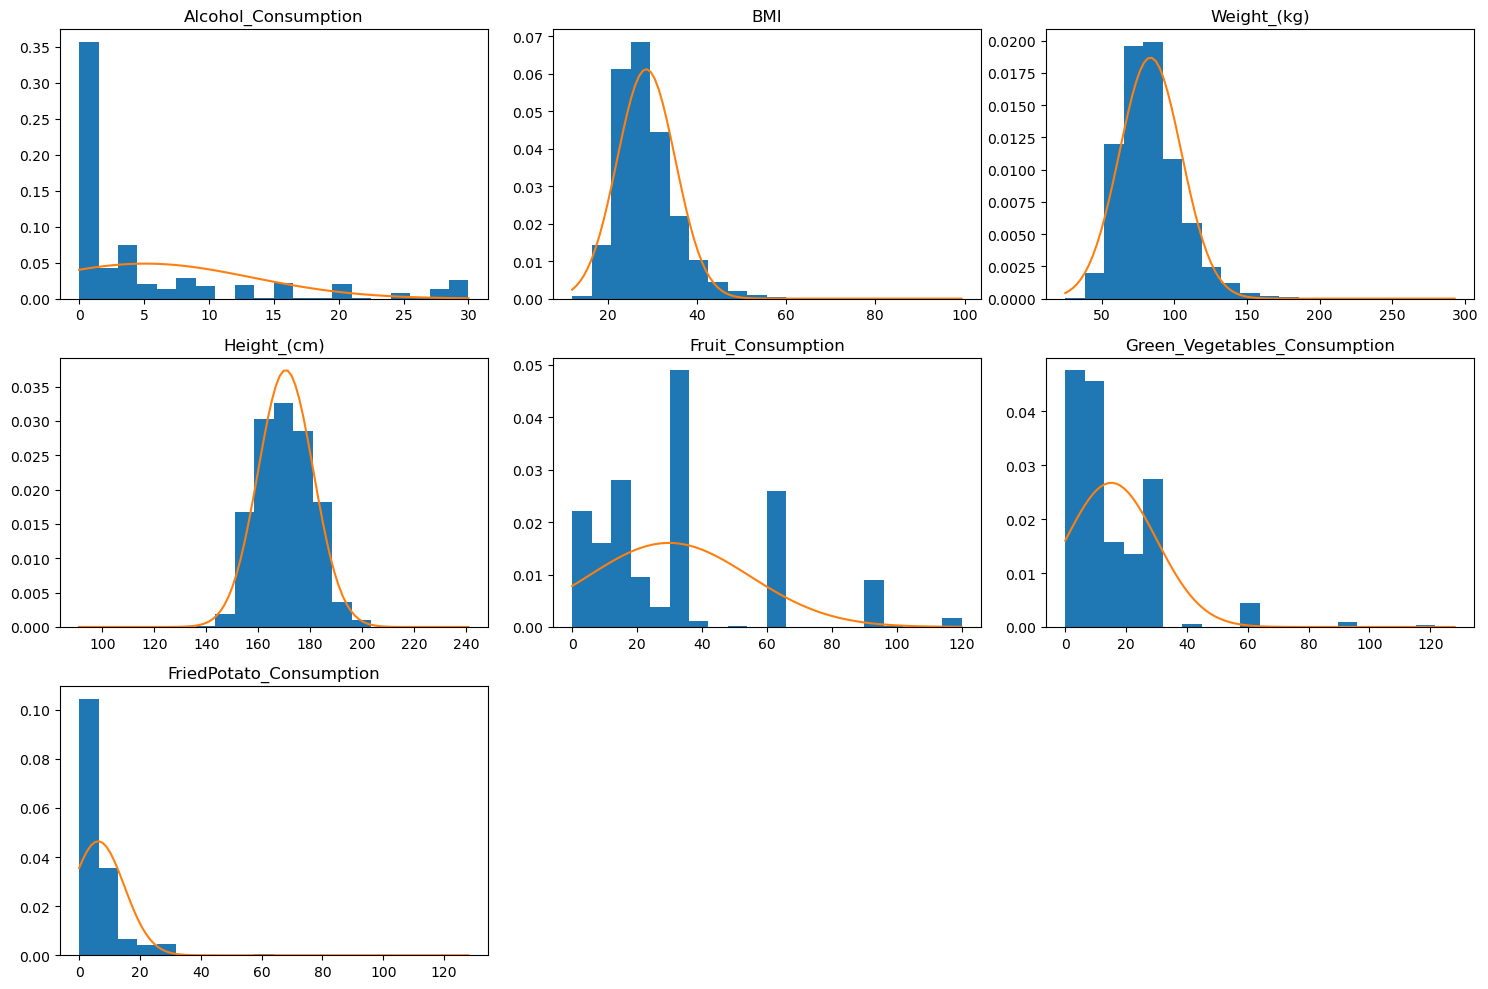

In [21]:
import numpy as np

pdf = df.select(columnas_numericas).toPandas()

plt.figure(figsize=(15,10))

for i, col in enumerate(columnas_numericas):
    plt.subplot(3,3,i+1)
    
    data = pdf[col].dropna()
    
    # Histograma
    plt.hist(data, bins=20, density=True)
    
    # Curva tipo campana (normal)
    mean = data.mean()
    std = data.std()
    
    x = np.linspace(data.min(), data.max(), 100)
    y = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean)/std)**2)
    
    plt.plot(x, y)
    plt.title(col)

plt.tight_layout()
plt.show()

## Interpretación de la forma de la distribución (asimetria y curtosis)

A partir de los valores de asimetria, curtosis y los histogramas con curva normal, se puede analizar la forma de cada variable:

- **Alcohol_Consumption:**  
  Presenta asimetria positiva alta y curtosis positiva
  En el grafico se observa que la mayoría de valores estan cerca de 0, pero hay algunos valores muy altos.  
  Esto indica una distribución sesgada a la derecha con presencia de valores extremos

- **BMI:**  
  Tiene asimetria positiva y curtosis positiva.  
  El grafico muestra una forma parecida a una campana, pero con una ligera inclinación hacia la derecha.  
  Esto indica una distribucion es casi normal, pero con algunos valores altos

- **Weight_(kg):**  
  Presenta asimetria positiva y curtosis positiva.  
  El gráfico muestra una distribución relativamente normal, pero con una cola hacia la derecha
  Esto indica que existen algunos pesos altos que afectan la distribución

- **Height_(cm):**  
  Tiene asimetría cercana a 0 y curtosis cercana a 0 
  El gráfico muestra una forma de campana muy clara
  Esto indica que la variable sigue una distribución normal

- **Fruit_Consumption:**  
  Presenta asimetria positiva y curtosis positiva 
  En el gráfico se observa dispersión y algunos valores altos
  Esto indica que no es una distribución normal y hay valores extremos

- **Green_Vegetables_Consumption:**  
  Tiene asimetra positiva alta y curtosis muy alta
  El gráfico muestra muchos valores bajos y algunos valores muy altos 
  Esto indica una distribución muy sesgada con presencia de muchos outliers

- **FriedPotato_Consumption:**  
  Presenta asimetria muy alta y curtosis extremadamente alta
  El gráfico muestra que casi todos los valores están bajos, pero hay algunos muy altos
  Esto indica una distribución altamente sesgada con muchos valores extremos


## Identificación de outliers (criterio IQR o Z-score)

In [23]:
quantiles = df.approxQuantile(columnas_numericas, [0.25, 0.75], 0.01)

from pyspark.sql.functions import col

for i, col_name in enumerate(columnas_numericas):
    q1 = quantiles[i][0]
    q3 = quantiles[i][1]
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = df.filter((col(col_name) < limite_inferior) | (col(col_name) > limite_superior)).count()
    
    print(col_name, "-> Outliers:", outliers)

Alcohol_Consumption -> Outliers: 36147
BMI -> Outliers: 10828
Weight_(kg) -> Outliers: 7326
Height_(cm) -> Outliers: 1055
Fruit_Consumption -> Outliers: 68225
Green_Vegetables_Consumption -> Outliers: 11878
FriedPotato_Consumption -> Outliers: 19456


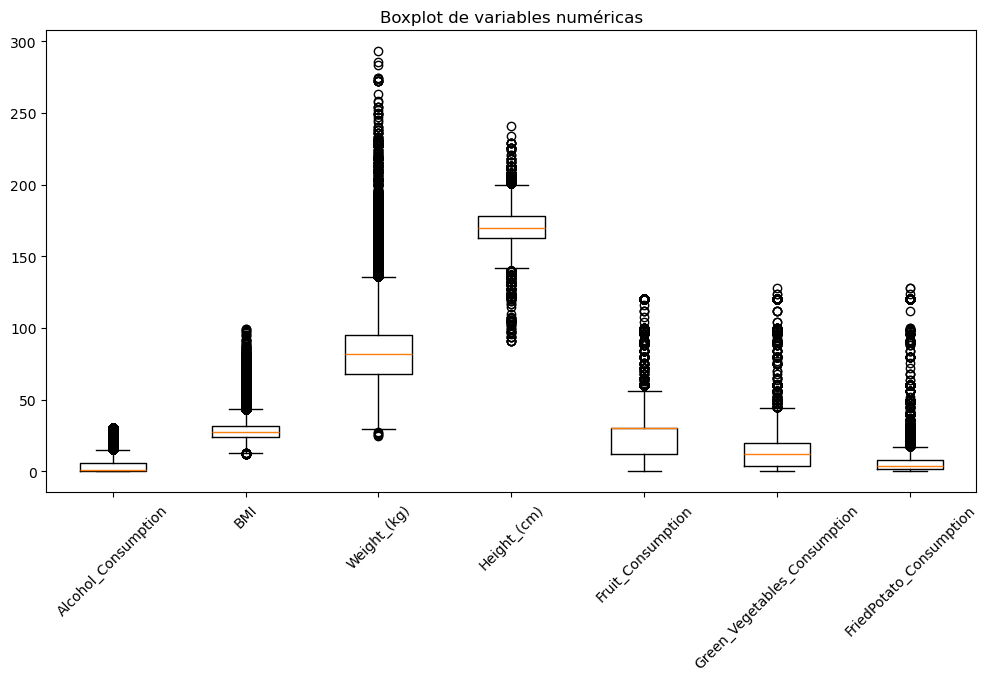

In [24]:
pdf = df.select(columnas_numericas).toPandas()

plt.figure(figsize=(12,6))
plt.boxplot([pdf[col].dropna() for col in columnas_numericas])
plt.xticks(range(1, len(columnas_numericas)+1), columnas_numericas, rotation=45)
plt.title("Boxplot de variables numéricas")
plt.show()

Se realizó un boxplot para visualizar los valores atipicos en las variables numericas.

- **Alcohol_Consumption:**  
  Se observan varios puntos fuera de la caja lo que indica presencia de outliers. La mayoría de valores son bajos pero hay algunos consumos altos

- **BMI:**  
  Se observan algunos valores extremos por encima de la caja lo que indica que hay personas con IMC alto

- **Weight_(kg):**  
  Presenta una gran cantidad de outliers especialmente en valores altos. Esto indica que hay personas con pesos muy elevados

- **Height_(cm):**  
  Tiene pocos outliers comparado con otras variables. La mayoria de datos estn concentrados, lo que indica una distribución más estable

- **Fruit_Consumption:**  
  Presenta varios outliers lo que indica que algunas personas consumen mucha más fruta que el promedio

- **Green_Vegetables_Consumption:**  
  Se observan varios valores extremos especialmente hacia valores altos

- **FriedPotato_Consumption:**  
  Presenta muchos outliers lo que indica que algunas personas consumen una gran cantidad de comida frita

## variables categóricas 

In [25]:
columnas_categoricas = [
    "Exercise",
    "Heart_Disease",
    "General_Health",
    "Smoking_History",
    "Sex",
    "Age_Category"
]

for col_name in columnas_categoricas:
    print(f"Frecuencia absoluta de {col_name}")
    df.groupBy(col_name).count().show()

Frecuencia absoluta de Exercise
+--------+------+
|Exercise| count|
+--------+------+
|      No| 69473|
|     Yes|239381|
+--------+------+

Frecuencia absoluta de Heart_Disease
+-------------+------+
|Heart_Disease| count|
+-------------+------+
|           No|283883|
|          Yes| 24971|
+-------------+------+

Frecuencia absoluta de General_Health
+--------------+------+
|General_Health| count|
+--------------+------+
|     Excellent| 55954|
|          Good| 95364|
|          Fair| 35810|
|     Very Good|110395|
|          Poor| 11331|
+--------------+------+

Frecuencia absoluta de Smoking_History
+---------------+------+
|Smoking_History| count|
+---------------+------+
|             No|183590|
|            Yes|125264|
+---------------+------+

Frecuencia absoluta de Sex
+------+------+
|   Sex| count|
+------+------+
|Female|160196|
|  Male|148658|
+------+------+

Frecuencia absoluta de Age_Category
+------------+-----+
|Age_Category|count|
+------------+-----+
|       65-69|3

In [26]:
total = df.count()

for col_name in columnas_categoricas:
    print(f"Frecuencia relativa de {col_name}")
    df.groupBy(col_name) \
      .count() \
      .withColumn("frecuencia_relativa", col("count")/total) \
      .show()

Frecuencia relativa de Exercise
+--------+------+-------------------+
|Exercise| count|frecuencia_relativa|
+--------+------+-------------------+
|      No| 69473|0.22493799659385988|
|     Yes|239381| 0.7750620034061401|
+--------+------+-------------------+

Frecuencia relativa de Heart_Disease
+-------------+------+-------------------+
|Heart_Disease| count|frecuencia_relativa|
+-------------+------+-------------------+
|           No|283883| 0.9191495010587527|
|          Yes| 24971|0.08085049894124732|
+-------------+------+-------------------+

Frecuencia relativa de General_Health
+--------------+------+-------------------+
|General_Health| count|frecuencia_relativa|
+--------------+------+-------------------+
|     Excellent| 55954| 0.1811665058571364|
|          Good| 95364| 0.3087672492504549|
|          Fair| 35810|0.11594475059413185|
|     Very Good|110395| 0.3574342569628368|
|          Poor| 11331|0.03668723733544005|
+--------------+------+-------------------+

Frecuenc

## Frecuencias absolutas y relativas

Se calcularon las frecuencias absolutas y relativas de varias variables categóricas del datasetión

- **Exercise:**  
  La mayoría de las personas sí realiza actividad física.  
  El 77.51% reond **Yes** y el 22.49% oeon**No**.  
  Esto muestra que la población del dataset es mayormente activa físicamente.

- **Heart_Disease:**  
  La mayoría de las personas no presenta enfermedad caovascular.  
  El 91.9 rpondió **No** y el 8.0 rió **Yes**.  
  Esto indica que los casos con enfermedad son menos frecuenes en la base.

- **General_Health:**  
a  La categoría s frecuen es **Very Good** con 34%, guida de **Goo* con 30.% y **Excellent** con 18.12%.  
 Lasaterías*Fair** y **Poor** tienemenor proporción.  
  Esto muestra que gran parte de las personas percibe su salud como buena o muy buena.

- **Smoking_History:**  
El9.44% respondió **No** el .56% respondió **Yes**.  
  Esto indica que hay una proporción importante de personas con historial de tabaquismo.

- **Sex:**  
  La distribución entre hombres y mujeres es bastante equilibrada.  
  El 51.87% son mujeres y el 48.13% son hombres.

- **Age_Category:**  
  Las categorías de ad comar freenc son 65-69**, **60-64** y **70-74**.  
  Esto indica que una parte importante de la población del dataset cltos mayores.

### Conclusión

Las frecuencias aosolutaa y relativas permiten ver cómo está distribuida la poblacin en cada categoría.

En este caso, se observa que la mayoría de personas realiza ejercicio, no presenta enfermedad cardiovascular y reporta una salud general buena o muy buena. Además, hay una alta presencia de personas en edades medias y mayores, lo cual es importante para el análisis del riesgo cardiovascular.

## Moda y numero de categorias unicas

In [28]:
for col_name in columnas_categoricas:
    print(f"Moda de {col_name}")
    df.groupBy(col_name).count().orderBy("count", ascending=False).show(1)

Moda de Exercise
+--------+------+
|Exercise| count|
+--------+------+
|     Yes|239381|
+--------+------+
only showing top 1 row

Moda de Heart_Disease
+-------------+------+
|Heart_Disease| count|
+-------------+------+
|           No|283883|
+-------------+------+
only showing top 1 row

Moda de General_Health
+--------------+------+
|General_Health| count|
+--------------+------+
|     Very Good|110395|
+--------------+------+
only showing top 1 row

Moda de Smoking_History
+---------------+------+
|Smoking_History| count|
+---------------+------+
|             No|183590|
+---------------+------+
only showing top 1 row

Moda de Sex
+------+------+
|   Sex| count|
+------+------+
|Female|160196|
+------+------+
only showing top 1 row

Moda de Age_Category
+------------+-----+
|Age_Category|count|
+------------+-----+
|       65-69|33434|
+------------+-----+
only showing top 1 row



In [29]:
from pyspark.sql.functions import countDistinct

df.select(
    countDistinct("Exercise"),
    countDistinct("Heart_Disease"),
    countDistinct("General_Health"),
    countDistinct("Smoking_History"),
    countDistinct("Sex"),
    countDistinct("Age_Category")
).show()

+------------------------+-----------------------------+------------------------------+-------------------------------+-------------------+----------------------------+
|count(DISTINCT Exercise)|count(DISTINCT Heart_Disease)|count(DISTINCT General_Health)|count(DISTINCT Smoking_History)|count(DISTINCT Sex)|count(DISTINCT Age_Category)|
+------------------------+-----------------------------+------------------------------+-------------------------------+-------------------+----------------------------+
|                       2|                            2|                             5|                              2|                  2|                          13|
+------------------------+-----------------------------+------------------------------+-------------------------------+-------------------+----------------------------+



la moda permite identificar cual es el valor más común en cada variable. En este caso se observa que la mayoria de las personas sí realiza ejercicio, no presenta enfermedad cardiovascular, no ha fumado y percibe su salud como “Very Good (muy buena)”. Ademas, la mayoria de los registros corresponden a mujeres y a personas en el rango de edad de 65-69 años. Esto nos da una idea clara de como es la población del dataset.

Por otro lado, el número de categorías muestra que la mayoría de variables tienen pocas opciones (como sí/no), lo que facilita el análisis. Sin embargo, la variable de edad tiene más categorías, lo que indica mayor variedad en los datos. En general el dataset es facil de interpretar y permite hacer comparaciones claras entre los diferentes grupos.

## Tablas de contingencia si hay relaciones entre categóricas

In [30]:

df.groupBy("Exercise", "Heart_Disease").count().show()
df.groupBy("General_Health", "Heart_Disease").count().show()
df.groupBy("Smoking_History", "Heart_Disease").count().show()

+--------+-------------+------+
|Exercise|Heart_Disease| count|
+--------+-------------+------+
|     Yes|          Yes| 15967|
|      No|           No| 60469|
|     Yes|           No|223414|
|      No|          Yes|  9004|
+--------+-------------+------+

+--------------+-------------+------+
|General_Health|Heart_Disease| count|
+--------------+-------------+------+
|          Fair|           No| 29021|
|          Poor|           No|  7729|
|     Excellent|          Yes|  1115|
|     Excellent|           No| 54839|
|          Good|          Yes|  8643|
|          Good|           No| 86721|
|     Very Good|          Yes|  4822|
|          Poor|          Yes|  3602|
|          Fair|          Yes|  6789|
|     Very Good|           No|105573|
+--------------+-------------+------+

+---------------+-------------+------+
|Smoking_History|Heart_Disease| count|
+---------------+-------------+------+
|            Yes|          Yes| 14584|
|             No|           No|173203|
|            Ye

## Tablas de contingencia

A partir de las tablas de contingencia se observa que la actividad fisica si tiene relación con la enfermedad cardiovascular. Entre las personas que hacen ejercicio, aproximadamente el **6.67%** presenta enfermedad (15,967 de 239,381) mientras que en las personas que no hacen ejercicio este valor sube a aproximadamente **12.96%** (9,004 de 69,473). Esto muestra que las personas que no realizan actividad física tienen casi el doble de probabilidad de presentar enfermedad.Por otro lado, en el estado de salud general se observa que a medida que la salud empeora, aumenta el porcentaje de enfermedad en “Excellent” es alrededor de **1.95%**, en “Very Good” **4.37%**, en “Good” **9.06%**, en “Fair” **18.97%** y en “Poor” llega a **31.79%**, lo que indica una relación clara entre peor salud y mayor riesgo.

Por otro lado, el historial de tabaquismo también muestra una diferencia importante. Entre las personas que han fumado aproximadamente el **11.64%** presenta enfermedad cardiovascular (14,584 de 125,264), mientras que en las personas que no han fumado este valor es de alrededor de **5.66%** (10,387 de 183,590). Esto indica que el tabaquismo esta asociado con un mayor riesgo. estas relaciones permiten confirmar las hipótesis planteadas, ya que se observa que factores como la falta de ejercicio, peor estado de salud y el tabaquismo están relacionados con una mayor presencia de enfermedad cardiovascular.

# 4 Consultas con Spark SQL

In [34]:
# Línea 1: Registrar el DataFrame como tabla temporal
df.createOrReplaceTempView("mi_tabla")  

# Línea 2: Consulta con filtro WHERE
consulta1 = spark.sql("SELECT * FROM mi_tabla WHERE `Height_(cm)` > 100")  
consulta1.show(5)  

# Línea 3: Consulta con GROUP BY y agregación
consulta2 = spark.sql("""
    SELECT General_Health,  
           COUNT(*) as cantidad,  
           AVG(Alcohol_Consumption) as promedio 
    FROM mi_tabla
    GROUP BY General_Health 
    ORDER BY cantidad DESC  
""")
consulta2.show()  

# Línea 4: Consulta con funciones de agregación
consulta3 = spark.sql("""
    SELECT MIN(Alcohol_Consumption) as minimo,  
           MAX(Alcohol_Consumption) as maximo,  
           AVG(Alcohol_Consumption) as promedio,  
           SUM(Alcohol_Consumption) as suma_total  
    FROM mi_tabla
""")
consulta3.show()

+--------------+--------------------+--------+-------------+-----------+------------+----------+--------+---------+------+------------+-----------+-----------+-----+---------------+-------------------+-----------------+----------------------------+-----------------------+
|General_Health|             Checkup|Exercise|Heart_Disease|Skin_Cancer|Other_Cancer|Depression|Diabetes|Arthritis|   Sex|Age_Category|Height_(cm)|Weight_(kg)|  BMI|Smoking_History|Alcohol_Consumption|Fruit_Consumption|Green_Vegetables_Consumption|FriedPotato_Consumption|
+--------------+--------------------+--------+-------------+-----------+------------+----------+--------+---------+------+------------+-----------+-----------+-----+---------------+-------------------+-----------------+----------------------------+-----------------------+
|          Poor|Within the past 2...|      No|           No|         No|          No|        No|      No|      Yes|Female|       70-74|      150.0|      32.66|14.54|            Yes|

## Explicación del código Spark SQL

Primero se crea una tabla temporal con el DataFrame Esto sirve para poder usar SQL sobre los datos

Luego se hace una consulta con filtro (WHERE) donde se seleccionan solo los datos que cumplen una condición. Después se muestran los 5 primeros  resultados

Después se agrupan los datos (GROUP BY) por una variable y se calcula cuantos hay y su promedio también se ordenan los resultados de manera descendiente

Por ultimo se calculan valores generales como el mínimo, máximo, promedio y suma de una variable

## Interpretación de los resultados

En la primera consulta se observan algunos registros del dataset filtrados por altura permitiendo ver ejemplos reales de las personas en la base, incluyendo sus habitos, estado de salud y si tienen o no enfermedad cardiovascular. Se puede notar que hay variedad en los datos, como personasque hacen o no ejercicio, diferentes edades y distintos estados de salud.

En la segunda consulta, al agrupar por estado de salud general, se observa que la mayoria de personas estan en categorías como "Very Good" y "Good". Ademas, el consumo promedio de alcohol es mayor en personas con mejor percepción de salud, como "Excellent" y "Very Good", mientras que en estados como "Fair" y "Poor" el consumo es menor.

En la tercera consulta se muestran valores generales del consumo de alcohol. Se observa que el mínimo es 0 y el máximo es 30, lo que indica que hay personas que no consumen alcohol y otras con consumo alto. El promedio es de aproximadamente 5.09, lo que sugiere un consumo moderado en general la suma total refleja el consumo acumulado en toda la población

# 5 Matriz de correlaciones

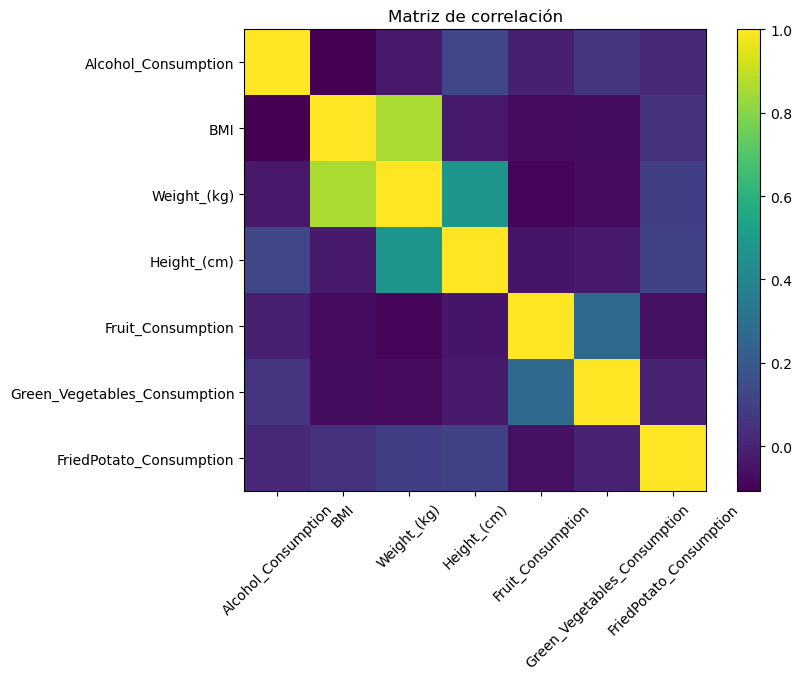

In [36]:
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(columnas_numericas)), columnas_numericas, rotation=45)
plt.yticks(range(len(columnas_numericas)), columnas_numericas)
plt.title("Matriz de correlación")
plt.show()


A partir de la matriz de correlacionse observa que en general las relaciones entre variables son bajas, lo que indica que la mayoría de factores analizados como el consumo las medidas físicas y habitos no dependen fuertemente unos de otros y aportan información diferente dentro del análisis.

Las 3 correlaciones positivas más fuertes son:

- **BMI y Weight_(kg):** correlacion alta positiva  
- **Weight_(kg) y Height_(cm):** correlacion moderada positiva  
- **Fruit_Consumption y Green_Vegetables_Consumption:** correlacion moderada positiva  

Estas relaciones tienen sentido en el contexto del problema. El BMI depende directamente del peso, por lo que su alta relacion es esperada. las personas mas altas tienden a tener mayor peso y observando frutas y verduras, se evidencia que los habitos saludables suelen ir juntos, es decir, quien consume frutas también tiende a consumir verduras.

En cuanto a las correlaciones negativas, no se observan relaciones fuertes. Las pocas que aparecen son muy cercanas a cero, lo que indica que no hay relaciones inversas significativas entre las variables.

Relacionando estos resultados con el análisis exploratorio (EDA) y las hipótesis planteadas, se puede decir que las variables de estilo de vida (como consumo de alcohol, comida o actividad física) no tienen una relación lineal fuerte entre sí, lo que sugiere que el riesgo de enfermedad cardiovascular no depende de un solo factor, sino de la combinacion de varios

En el análisis descriptivo se observo que variables como el consumo de papas fritas, alcohol y verduras tienen alta dispersión y presencia de outliers, lo cual también explica por qué sus correlaciones son bajas: los comportamientos son muy variados entre personas.Esto apoya las preguntas de investigación planteadas por ejemplo, aunque el ejercicio o el consumo de alcohol no muestran alta correlación con otras variables en las tablas de contingencia sí se evidencio relacion con la enfermedad cardiovascular.

# 6 Conclusiones 

## Conclusiones

### 1. Respuesta a las preguntas de investigación

**Pregunta 1: ¿Las personas que no realizan actividad física tienen mayor riesgo de enfermedad cardiovascular?**  

Si. porque en la tabla de contingencia se observa que las personas que no hacen ejercicio tienen una mayor proporcion de enfermedad cardiovascular (9004 casos) en comparación con quienes hacen ejercicio. Ademas, el porcentaje de personas con enfermedad es mayor en el grupo que no realiza actividad física. Esto indica que el ejercicio va a influir en el riesgo.

**Pregunta 2: ¿El consumo de alcohol está relacionado con la enfermedad cardiovascular?**  

No de forma clara porque en la  matriz de correlación se observo que el consumo de alcohol tiene una relación muy baja con otras variables. Además, en el análisis descriptivo no se evidencio una relación fuerte o directa con la enfermedad cardiovascular por lo que no se puede afirmar una relación clara.

**Pregunta 3: ¿Las personas con peor salud general tienen mayor probabilidad de enfermedad cardiovascular?**  

Sí. En la tabla de contingencia se observa que las personas con estado de salud “Poor” y “Fair” tienen una mayor proporción de enfermedad cardiovascular en comparación con quienes tienen “Very Good” o “Excellent”. Esto muestra una relación clara entre peor salud general y mayor riesgo.


### 2. Validación de hipótesis

- **Hipótesis 1 (ejercicio):** Se confirma, ya que las personas que no hacen ejercicio presentan mayor proporción de enfermedad cardiovascular.  
- **Hipótesis 2 (alcohol):** No se confirma completamente, ya que no se encontró una relación fuerte en el análisis 
- **Hipótesis 3 (salud general):** Se confirma, porque el riesgo aumenta a medida que empeora la salud general


### 3. Limitaciones del análisis

- No se analizan variables medicas más profundas, lo que limita el análisis a factores generales.   
- El dataset es de Estados Unidos, por lo que los resultados pueden no representar otras poblaciones.


### 4. Propuestas de análisis futuros

- Construir un modelo predictivo (como regresión logística o machine learning) para predecir el riesgo de enfermedad cardiovascular. 
- Realizar análisis más avanzados como clustering para encontrar perfiles de riesgo.  


### Conclusión general

El análisis muestra que la enfermedad cardiovascular esta relacionada con múltiples factores especialmente el estado de salud general y la actividad física. Sin embargo, no todas las variables tienen relaciones fuertes entre sí, lo que indica que es un problema complejo que requiere análisis más avanzados para su comprensión completa.